In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)

from sklearn.ensemble import RandomForestClassifier

SEED = 42

cohort = pd.read_csv("cohort.csv")
# print(cohort.columns.tolist())

print("Top missings:")
print((cohort.isna().mean() * 100).sort_values(ascending=False).head(10))

print(f"Duplicate count: {cohort.duplicated().sum()}")


Top missings:
lab_lactate            47.617655
lab_ph                 45.921148
vital_map               8.105362
vital_dbp               8.089967
vital_sbp               8.080730
vital_temperature_f     6.027064
lab_hemoglobin          3.737857
lab_wbc                 3.724002
lab_platelets           3.702449
lab_glucose             3.463830
dtype: float64
Duplicate count: 0


In [12]:
print(cohort.columns)

Index(['hadm_id', 'subject_id', 'stay_id', 'los', 'long_icu_stay',
       'marital_status', 'hospital_expire_flag', 'los_hospital_hrs',
       'is_emergency', 'race_group', 'insurance_group', 'gender', 'anchor_age',
       'dod_known', 'cm_aki', 'cm_alcohol', 'cm_cad', 'cm_ckd', 'cm_copd',
       'cm_diabetes', 'cm_heart_failure', 'cm_hypertension', 'lab_anion_gap',
       'lab_bicarbonate', 'lab_chloride', 'lab_creatinine', 'lab_glucose',
       'lab_hematocrit', 'lab_hemoglobin', 'lab_lactate', 'lab_ph',
       'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_urea_nitrogen',
       'lab_wbc', 'vital_dbp', 'vital_gcs_eye', 'vital_gcs_motor',
       'vital_gcs_verbal', 'vital_heart_rate', 'vital_map', 'vital_resp_rate',
       'vital_sbp', 'vital_spo2', 'vital_temperature_f', 'gcs_total'],
      dtype='str')


In [ ]:
TARGET = "hospital_expire_flag"


cohort = cohort.drop(columns= ["subject_id", "hadm_id", "stay_id"] ) # ID Cols 
cohort = cohort.drop(columns= ["marital_status"]) # noisy 
cohort = cohort.drop(columns=["long_icu_stay", "los_hospital_hrs", "los", "dod_known"])
cohort = cohort.drop(columns= ["lab_lactate", "lab_ph"])

cohort = cohort.replace(["", "nan", "None", "unknown", "Unknown"], np.nan) # standardised nan

# Median imputation
num_cols = cohort.select_dtypes(include="number").columns.tolist()


numeric_impute_cols = [c for c in num_cols if c != TARGET]

for col in numeric_impute_cols:
    cohort[col] = cohort[col].fillna(cohort[col].median())

# cat_cols = cohort.select_dtypes(include=["object", "category"]).columns.tolist()
# print(cat_cols)

cohort = cohort.dropna(subset=["race_group", "insurance_group"])


cohort["age_group"] = pd.cut(
    cohort["anchor_age"],
    bins=[0, 40, 60, 200],
    labels=["under40", "40to60", "over60"]
)
cohort = cohort.drop(columns=["anchor_age"])

print("\nRemaining missing values:")
print(cohort.isna().sum().sort_values(ascending=False).head(10))



Remaining missing values:
hospital_expire_flag    0
is_emergency            0
race_group              0
insurance_group         0
gender                  0
cm_aki                  0
cm_alcohol              0
cm_cad                  0
cm_ckd                  0
cm_copd                 0
dtype: int64


In [14]:
# sensative demographics (pratham use this for bias )
SENSITIVE = ["gender", "race_group", "insurance_group", "age_group"]
sensitive_df = cohort[SENSITIVE].copy()


cohort_encoded = pd.get_dummies(cohort, columns=["race_group", "insurance_group", "age_group"], drop_first=False)

# Feature and target split
feature_cols = [c for c in cohort_encoded.columns if c != TARGET]
X = cohort_encoded[feature_cols]
y = cohort[TARGET]

print(f"X shape: {X.shape}")
print(f"Features: {feature_cols}")

X shape: (64957, 43)
Features: ['is_emergency', 'gender', 'cm_aki', 'cm_alcohol', 'cm_cad', 'cm_ckd', 'cm_copd', 'cm_diabetes', 'cm_heart_failure', 'cm_hypertension', 'lab_anion_gap', 'lab_bicarbonate', 'lab_chloride', 'lab_creatinine', 'lab_glucose', 'lab_hematocrit', 'lab_hemoglobin', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_urea_nitrogen', 'lab_wbc', 'vital_dbp', 'vital_gcs_eye', 'vital_gcs_motor', 'vital_gcs_verbal', 'vital_heart_rate', 'vital_map', 'vital_resp_rate', 'vital_sbp', 'vital_spo2', 'vital_temperature_f', 'gcs_total', 'race_group_ASIAN', 'race_group_BLACK', 'race_group_INDIGENOUS', 'race_group_OTHER', 'race_group_WHITE', 'insurance_group_government', 'insurance_group_private', 'age_group_under40', 'age_group_40to60', 'age_group_over60']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y
)

sens_test = sensitive_df.loc[X_test.index]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Train mortality rate: {y_train.mean():.2%}")
print(f"Test mortality rate : {y_test.mean():.2%}")

X_train: (51965, 43), X_test: (12992, 43)
Train mortality rate: 10.10%
Test mortality rate : 10.10%


In [16]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Scaling done")
print(f"X_train_scaled: {X_train_scaled.shape}")

Scaling done
X_train_scaled: (51965, 43)


In [17]:
print(X.columns.tolist())


['is_emergency', 'gender', 'cm_aki', 'cm_alcohol', 'cm_cad', 'cm_ckd', 'cm_copd', 'cm_diabetes', 'cm_heart_failure', 'cm_hypertension', 'lab_anion_gap', 'lab_bicarbonate', 'lab_chloride', 'lab_creatinine', 'lab_glucose', 'lab_hematocrit', 'lab_hemoglobin', 'lab_platelets', 'lab_potassium', 'lab_sodium', 'lab_urea_nitrogen', 'lab_wbc', 'vital_dbp', 'vital_gcs_eye', 'vital_gcs_motor', 'vital_gcs_verbal', 'vital_heart_rate', 'vital_map', 'vital_resp_rate', 'vital_sbp', 'vital_spo2', 'vital_temperature_f', 'gcs_total', 'race_group_ASIAN', 'race_group_BLACK', 'race_group_INDIGENOUS', 'race_group_OTHER', 'race_group_WHITE', 'insurance_group_government', 'insurance_group_private', 'age_group_under40', 'age_group_40to60', 'age_group_over60']


MODEL TRAINING


# Base line logistic regrssion with weight balancing

In [24]:
lr = LogisticRegression(max_iter=1000, random_state=SEED, class_weight="balanced")
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, lr_pred).ravel()

lr_results = {
    "accuracy":        accuracy_score(y_test, lr_pred),
    "precision":       precision_score(y_test, lr_pred, zero_division=0),
    "recall_death":    recall_score(y_test, lr_pred, pos_label=1, zero_division=0),
    "recall_survival": recall_score(y_test, lr_pred, pos_label=0, zero_division=0),
    "f1":              f1_score(y_test, lr_pred, zero_division=0),
    "roc_auc":         roc_auc_score(y_test, lr_prob),
    "fpr":             fp / (fp + tn),
    "fnr":             fn / (fn + tp),
}


Random Forest (balancing sub samples and forcing 5 sample leafs to prevent only surv leafs)

In [23]:
rf = RandomForestClassifier(n_estimators=100, random_state=SEED, class_weight="balanced_subsample", min_samples_leaf=5)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()

rf_results = {
    "accuracy":        accuracy_score(y_test, rf_pred),
    "precision":       precision_score(y_test, rf_pred, zero_division=0),
    "recall_death":    recall_score(y_test, rf_pred, pos_label=1, zero_division=0),
    "recall_survival": recall_score(y_test, rf_pred, pos_label=0, zero_division=0),
    "f1":              f1_score(y_test, rf_pred, zero_division=0),
    "roc_auc":         roc_auc_score(y_test, rf_prob),
    "fpr":             fp / (fp + tn),
    "fnr":             fn / (fn + tp),
}

In [25]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=100,
    random_state=SEED,
    eval_metric="logloss",
    verbosity=0,
    scale_pos_weight=neg/pos
)
xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, xgb_pred).ravel()

xgb_results = {
    "accuracy":        accuracy_score(y_test, xgb_pred),
    "precision":       precision_score(y_test, xgb_pred, zero_division=0),
    "recall_death":    recall_score(y_test, xgb_pred, pos_label=1, zero_division=0),
    "recall_survival": recall_score(y_test, xgb_pred, pos_label=0, zero_division=0),
    "f1":              f1_score(y_test, xgb_pred, zero_division=0),
    "roc_auc":         roc_auc_score(y_test, xgb_prob),
    "fpr":             fp / (fp + tn),
    "fnr":             fn / (fn + tp),
}


In [27]:
print("Logistic Regression")
for k, v in lr_results.items():
    print(f"  {k}: {v}")

print("Random Forest")
for k, v in rf_results.items():
    print(f"  {k}: {v}")

print("XGBoost")
for k, v in xgb_results.items():
    print(f"  {k}: {v}")

Logistic Regression
  accuracy: 0.7802493842364532
  precision: 0.28395407448893867
  recall_death: 0.7728658536585366
  recall_survival: 0.7810787671232877
  f1: 0.415318451771452
  roc_auc: 0.8498930447084865
  fpr: 0.21892123287671234
  fnr: 0.22713414634146342
Random Forest
  accuracy: 0.9114070197044335
  precision: 0.5760151085930123
  recall_death: 0.4649390243902439
  recall_survival: 0.9615582191780822
  f1: 0.5145508224377899
  roc_auc: 0.8848543737470764
  fpr: 0.038441780821917806
  fnr: 0.5350609756097561
XGBoost
  accuracy: 0.8582974137931034
  precision: 0.3813369223867205
  recall_death: 0.6478658536585366
  recall_survival: 0.8819349315068493
  f1: 0.48009036995199095
  roc_auc: 0.8683046901102572
  fpr: 0.11806506849315068
  fnr: 0.3521341463414634


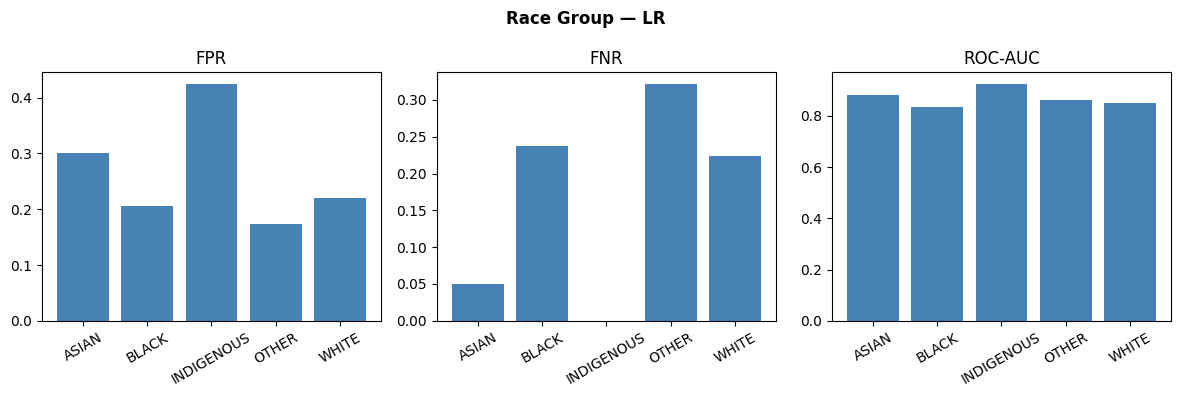

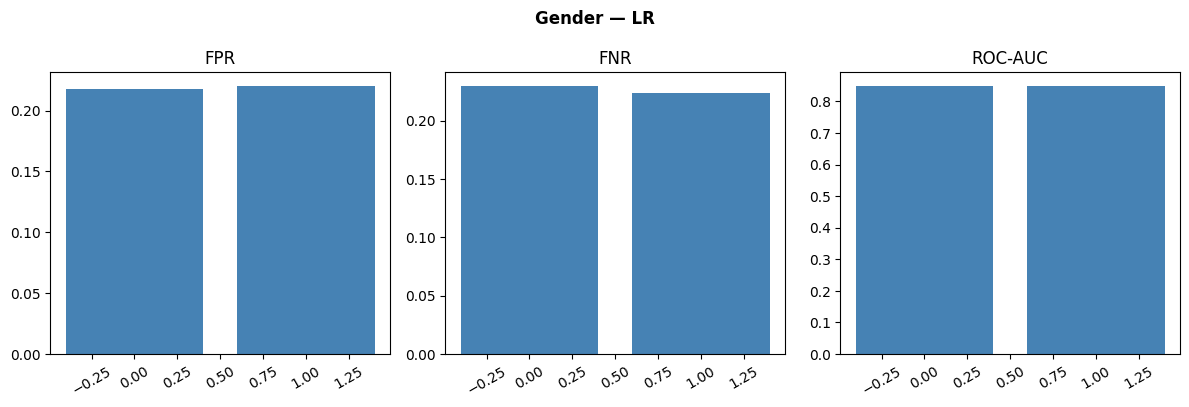

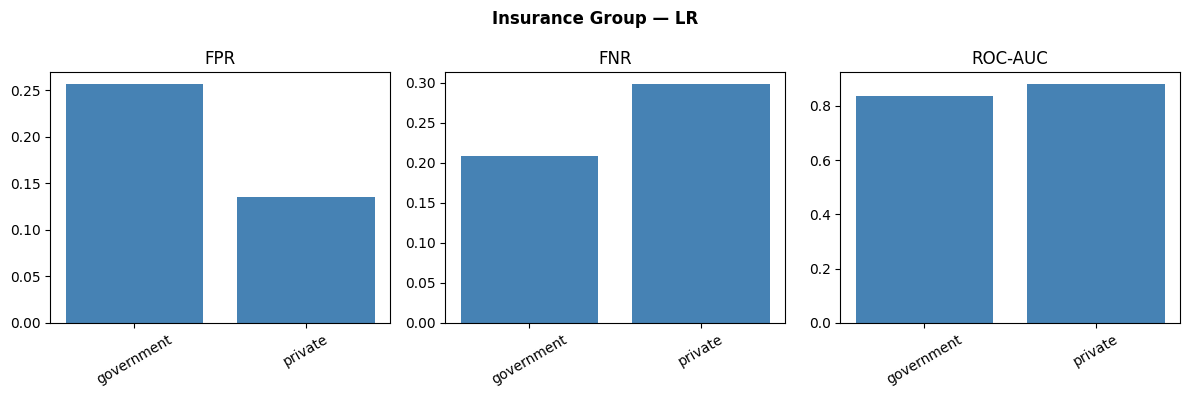

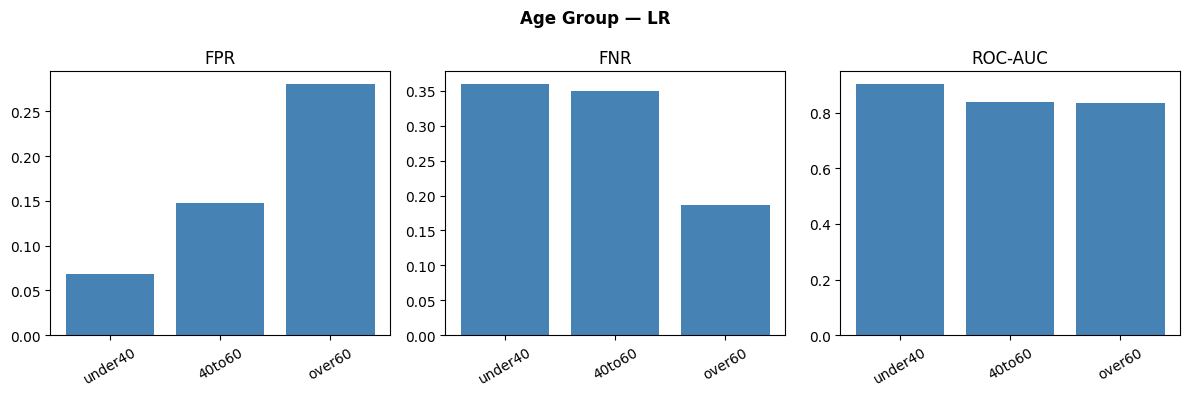

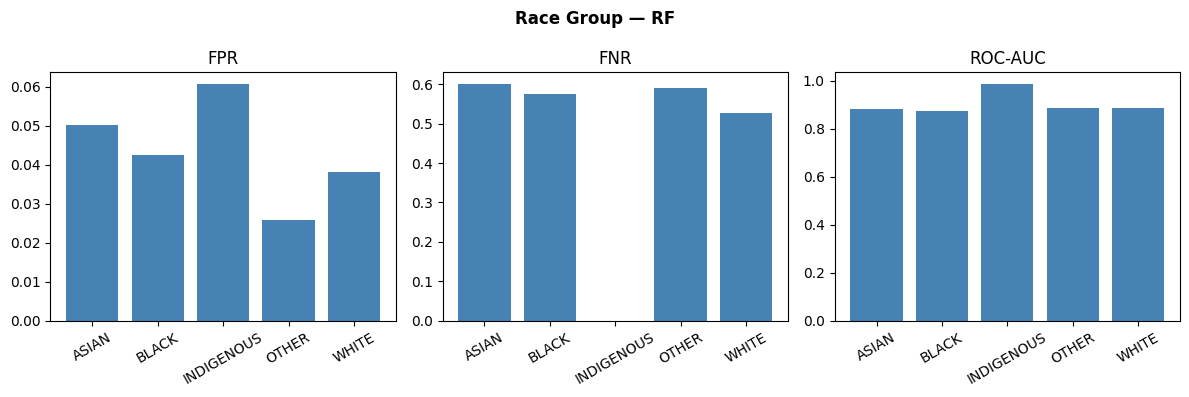

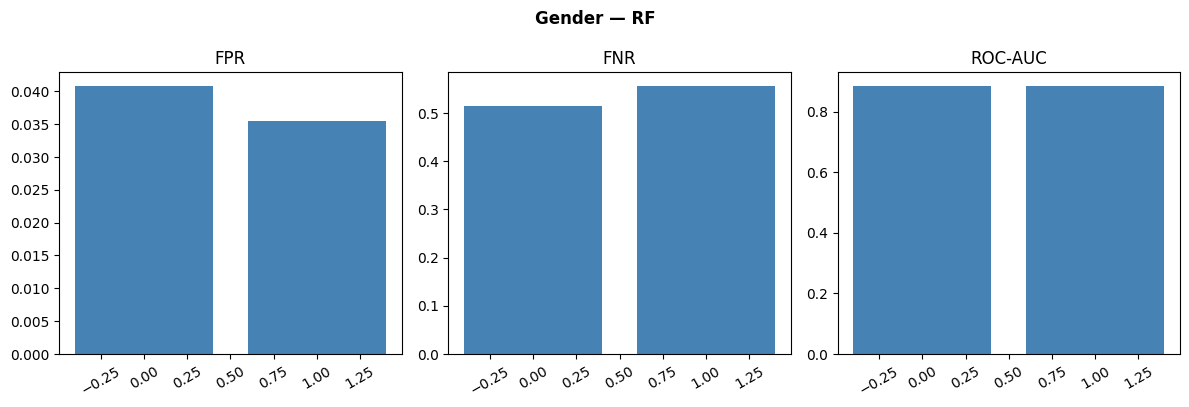

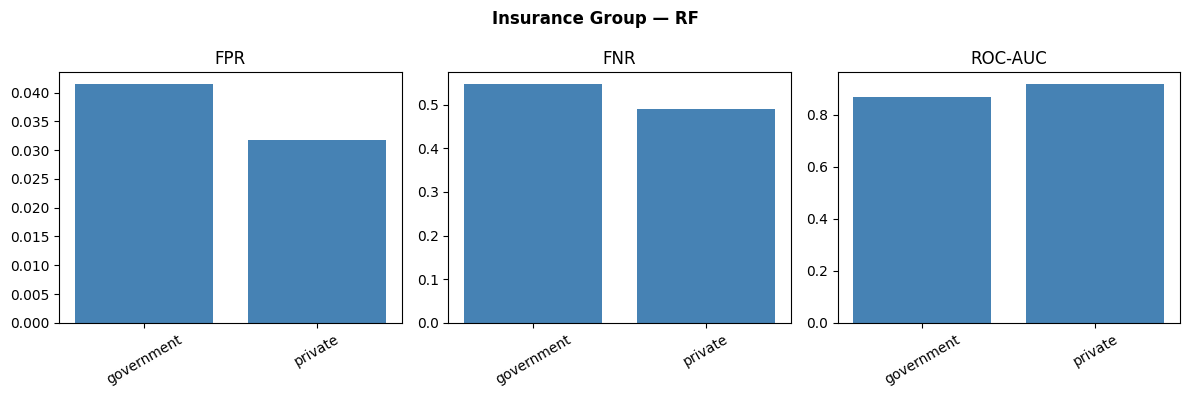

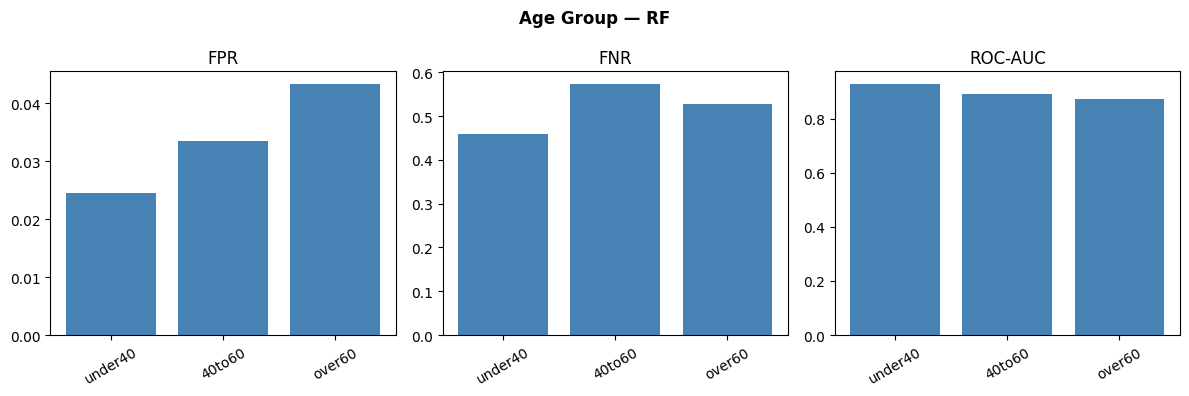

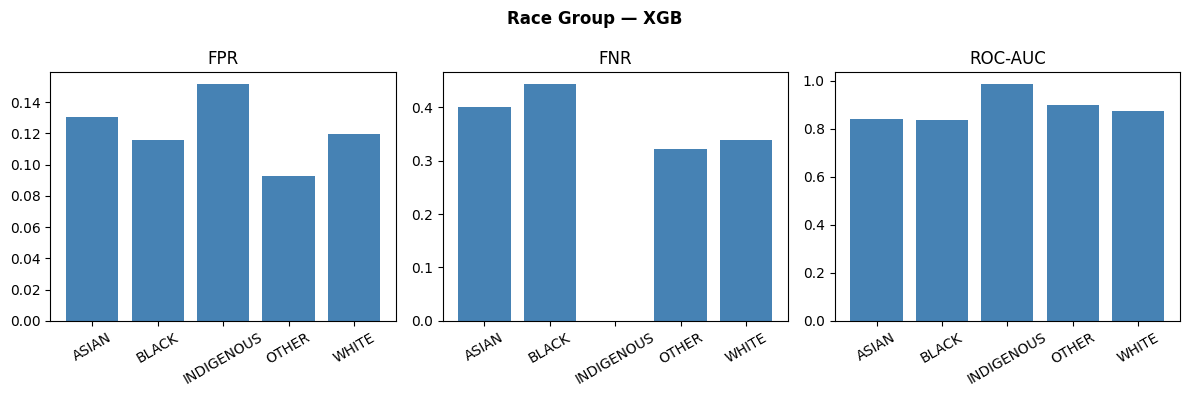

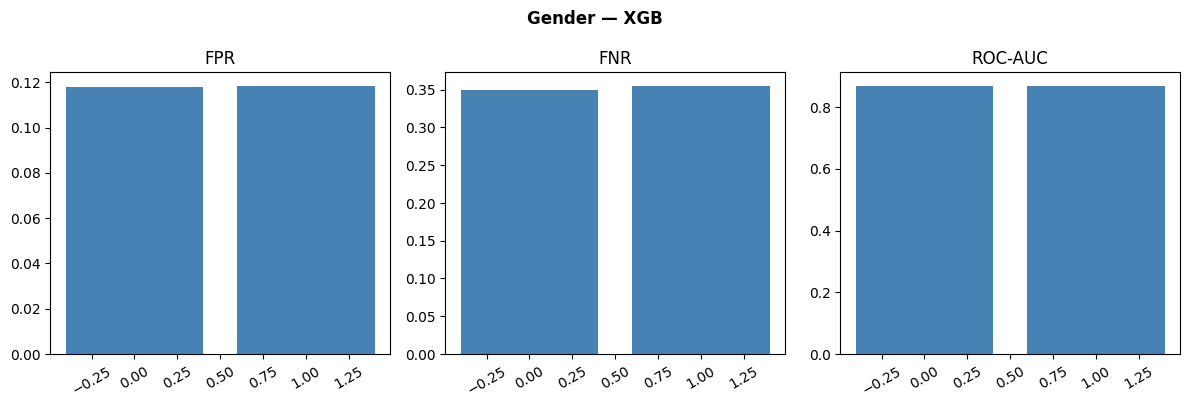

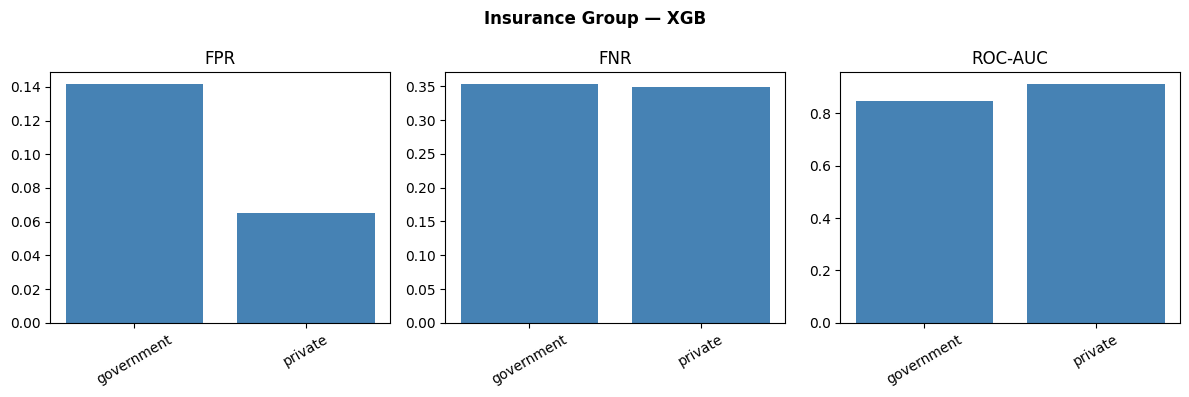

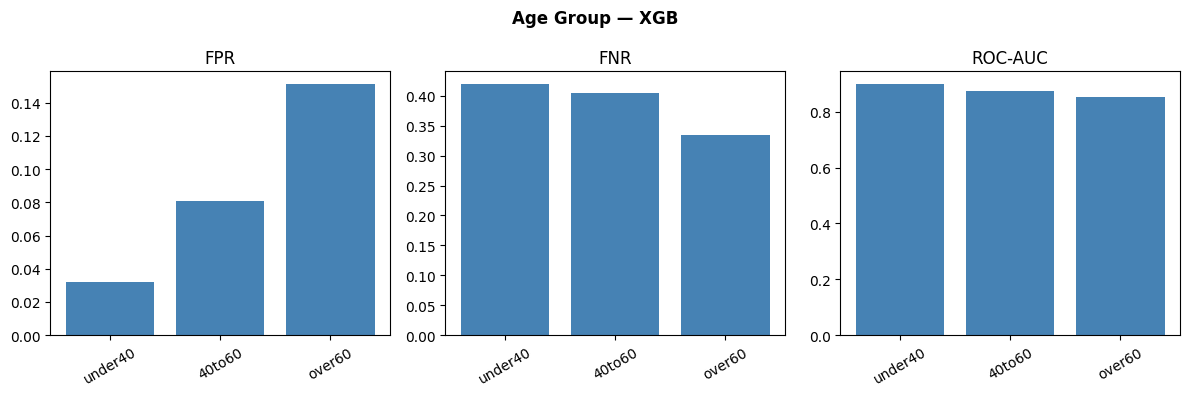

In [31]:
def plot_bias(attr, labels, pred_col, prob_col, model_name):
    metrics = {"FPR": [], "FNR": [], "ROC-AUC": []}

    for group in labels:
        gdf = test_df[test_df[attr] == group]
        y_true = gdf["y_true"].values
        y_pred = gdf[pred_col].values
        y_prob = gdf[prob_col].values
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        metrics["FPR"].append(fp / (fp + tn) if (fp + tn) > 0 else 0)
        metrics["FNR"].append(fn / (fn + tp) if (fn + tp) > 0 else 0)
        metrics["ROC-AUC"].append(roc_auc_score(y_true, y_prob) if len(np.unique(y_true)) > 1 else np.nan)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    fig.suptitle(f"{attr.replace('_', ' ').title()} — {model_name}", fontweight="bold")
    for ax, (metric, vals) in zip(axes, metrics.items()):
        ax.bar(labels, vals, color="steelblue")
        ax.set_title(metric)
        ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(f"{attr}_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()


for model_name, pred_col, prob_col in [("LR", "lr_pred", "lr_prob"),
                                        ("RF", "rf_pred", "rf_prob"),
                                        ("XGB", "xgb_pred", "xgb_prob")]:
    plot_bias("race_group",     ["ASIAN", "BLACK", "INDIGENOUS", "OTHER", "WHITE"], pred_col, prob_col, model_name)
    plot_bias("gender",         [0, 1],                                             pred_col, prob_col, model_name)
    plot_bias("insurance_group",["government", "private"],                          pred_col, prob_col, model_name)
    plot_bias("age_group",      ["under40", "40to60", "over60"],                    pred_col, prob_col, model_name)